# Tutorial

We start by importing Matplotlib and NumPy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

And the relevant ``exogaia`` classes.

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import BinaryModel
from exogaia.results import FitResults
from exogaia.sampler import MCMCSampler, NestedSampler

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


Let's set the seed of the random number generator for reproducibility.

In [3]:
np.random.seed(42)

## Gaia epoch astrometry

The ``EpochAstrometry`` class is used for storing Gaia epoch astrometry. In the future, we can either retrieve the data from the archive. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieving parameters from DR3. In this first example, we will simulate DR4 epoch astrometry for the star HD 135344 A.

In [4]:
source_id = 6199395656645840384  # HD 135344 A

In [5]:
primary_mass = (2.2, 0.1)  # (Msun)

In [6]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 2.20 +/- 0.10


Now we query the relevant stellar parameters from Gaia DR3. The parameters will be stored as attributes of the `EpochAstrometry` object, but also returned as list for convenience.

In [7]:
params = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA: 228.954 deg +/- 0.038 mas
Dec: -37.149 deg +/- 0.026 mas
Parallax: 7.411 +/- 0.040 mas
Proper motion in RA: -18.738 +/- 0.051 mas/yr
Proper motion in Dec: -24.008 +/- 0.035 mas/yr
G-band magnitude: 7.748


## Single star

We will first simulate epoch astrometry for a single star. As example, we use the retrieved stellar parameters of HD 135344 A.

In [8]:
model_param = epoch_astrom.simulate_data(ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: single

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75


Next, we run a 5-parameter least-squares fit to determine the best-fit parameters and uncertainties of the stellar track.

In [9]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 1.201
RUWE = 1.096
Inflation factor = 1.100

Best-fit parameters:
   - RA = 228.953 deg +/- 0.016 mas
   - Dec = -37.162 deg +/- 0.011 mas
   - Parallax = 7.446 +/- 0.018 mas
   - mu in RA = -18.744 +/- 0.010 mas/yr
   - mu in Dec = -23.999 +/- 0.005 mas/yr


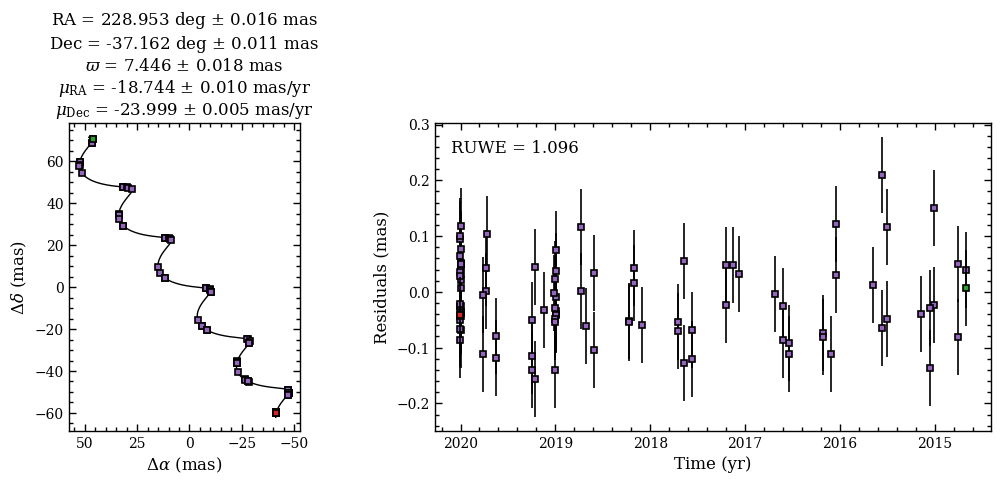

In [10]:
results = leastsq.singl_5param(plot_file='res_5param.png')

## Accelerating star

As a next example, we will simulate epoch astrometry for a 50 $M_\mathrm{J}$ companion on a 5 au orbit that will cause a detectable acceleration of the stellar proper motion. 

In [11]:
mass_1 = primary_mass[0]  # (Msun)
mass_2 = 0.05  # (Msun)

In [12]:
sma, ecc, inc, aop, pan, tau = 7., 0.0, np.radians(50.0), np.radians(0.0), np.radians(90.0), 0.5

In [13]:
model_param = epoch_astrom.simulate_data(mass_1=mass_1, mass_2=mass_2,
                                         sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.05
   - Semi-major axis (au) = 7.00
   - Eccentricity = 0.00
   - Inclination (deg) = 50.00
   - Argument of periastron (deg) = 0.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50


Let's plot the stellar orbit in comparison with the simulated 1D epoch astrometry.

In [14]:
bin_model = BinaryModel(epoch_astrometry=epoch_astrom)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.05
   - Semi-major axis (au) = 7.00
   - Eccentricity = 0.00
   - Inclination (deg) = 50.00
   - Argument of periastron (deg) = 0.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 0.89
RUWE = 0.94

----------
Plot orbit
----------



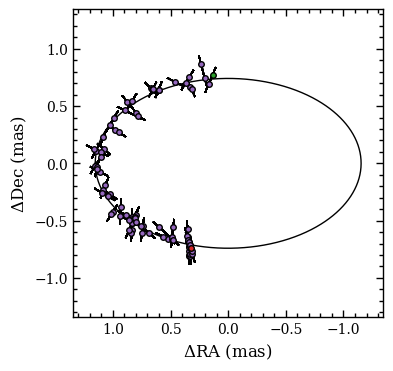

In [15]:
fig = bin_model.plot_orbit(model_param=model_param, plot_file=None)

We can now fit the epoch astrometry with a 5-parameter single star model.

In [16]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 3.753
RUWE = 1.937
Inflation factor = 1.944

Best-fit parameters:
   - RA = 229.792 deg +/- 0.028 mas
   - Dec = -37.173 deg +/- 0.019 mas
   - Parallax = 7.413 +/- 0.032 mas
   - mu in RA = -18.714 +/- 0.018 mas/yr
   - mu in Dec = -24.326 +/- 0.009 mas/yr


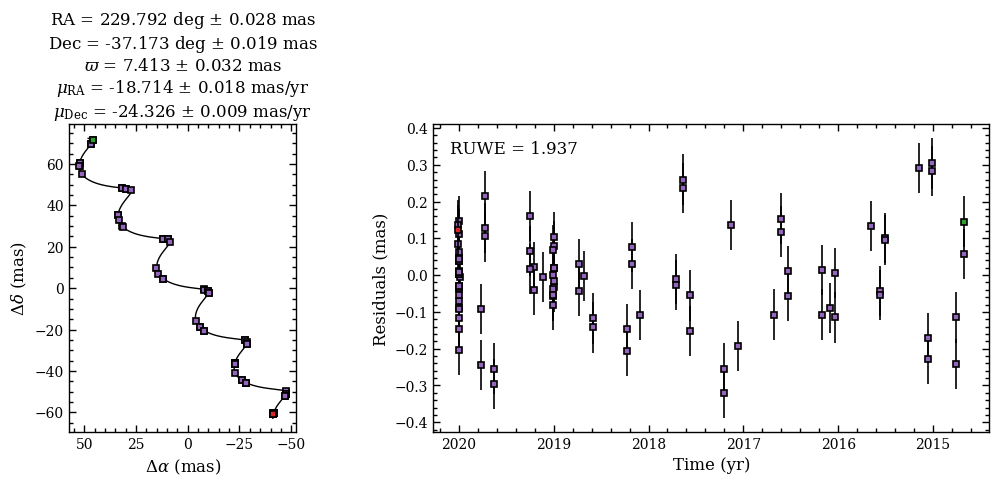

In [17]:
results = leastsq.singl_5param(plot_file='res_5param.png')

The RUWE from the single star model is 1.9, so we include an acceleration term in the fit.


--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 1.019
RUWE = 1.009
Inflation factor = 1.013

Best-fit parameters:
   - RA = 230.048 deg +/- 0.022 mas
   - Dec = -37.176 deg +/- 0.016 mas
   - Parallax = 7.416 +/- 0.017 mas
   - mu in RA = -18.726 +/- 0.010 mas/yr
   - mu in Dec = -24.305 +/- 0.005 mas/yr
   - dmu/dt in RA = -0.224 +/- 0.014 mas/yr^2
   - dmu/dt in Dec = 0.010 +/- 0.007 mas/yr^2


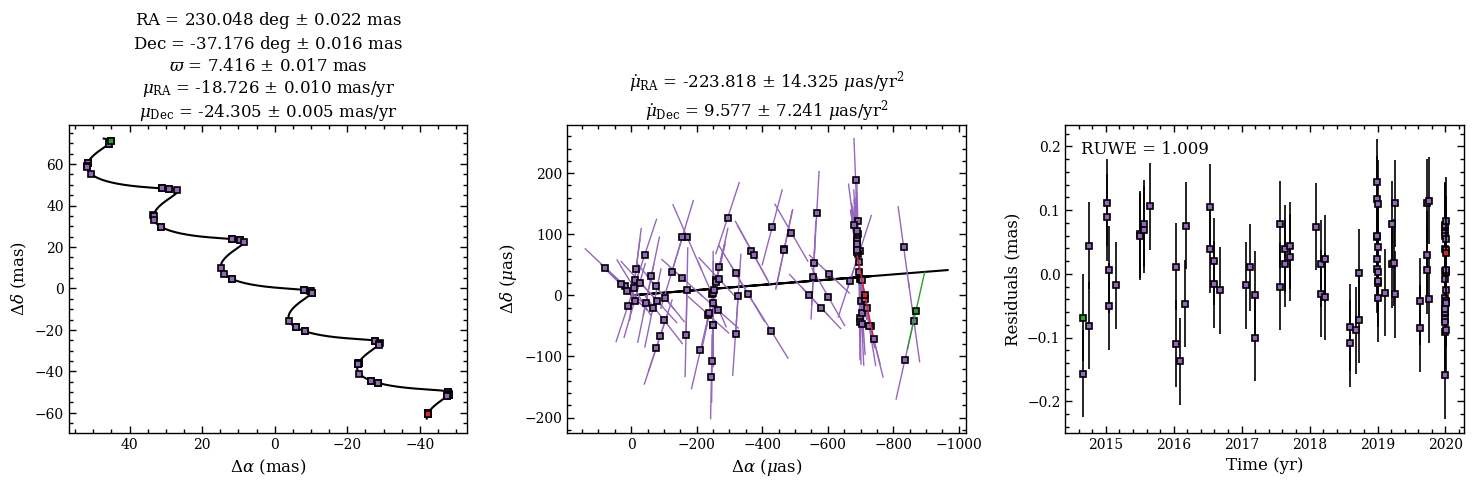

In [18]:
results = leastsq.accel_7param(plot_file='res_7param.png')

The RUWE decreased to 1.0 when including the acceleration. Let's check if the data also warrants including the acceleration derivative, so the second-order derivative of the proper motion.


--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 0.748
RUWE = 0.865
Inflation factor = 0.868

Best-fit parameters:
   - RA = 230.049 deg +/- 0.022 mas
   - Dec = -37.152 deg +/- 0.017 mas
   - Parallax = 7.408 +/- 0.017 mas
   - mu in RA = -18.707 +/- 0.024 mas/yr
   - mu in Dec = -24.375 +/- 0.015 mas/yr
   - dmu/dt in RA = -0.237 +/- 0.015 mas/yr^2
   - dmu/dt in Dec = 0.005 +/- 0.007 mas/yr^2
   - d^2mu/d^2t in RA = -0.031 +/- 0.032 mas/yr^3
   - d^2mu/d^2t in Dec = 0.077 +/- 0.015 mas/yr^3


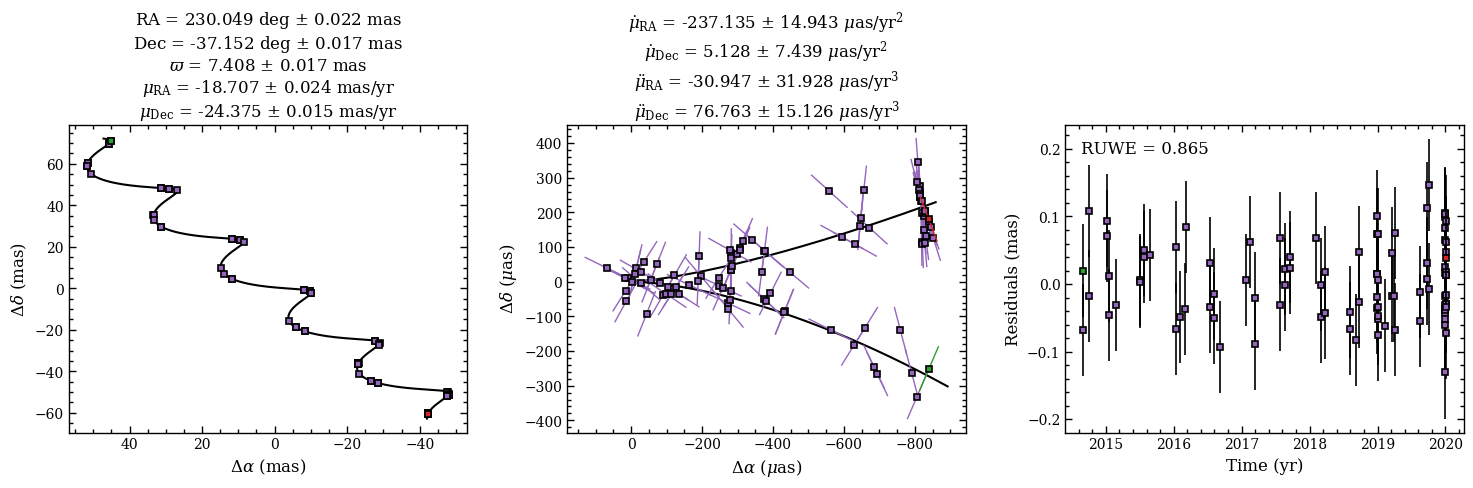

In [19]:
results = leastsq.accel_9param(plot_file='res_9param.png')

The RUWE decreased further to 0.9 and the second-order proper motion derivative is quite well constrained.

## Binary system

Now we simulate a binary system, but we provide the stellar parameters manually. We choose a smaller orbit such that most of the phase is well sampled by the simulated measurements.

In [20]:
sma, ecc, inc, aop, pan, tau = 2., 0.3, np.radians(60.0), np.radians(0.0), np.radians(90.0), 0.0
mass_1, mass_2 = 1.0, 0.01  # (Msun)
ra, dec, parallax, pmra, pmdec, phot_g_mean_mag = 50.0, 20.0, 25.0, -30.0, 30.0, 7.0

In [21]:
model_param = epoch_astrom.simulate_data(mass_1=mass_1, mass_2=mass_2,
                                         sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=ra, dec=dec, parallax=parallax, pmra=pmra, pmdec=pmdec, phot_g_mean_mag=phot_g_mean_mag)


-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 159.98 uas
AL scan uncertainty (per transit) = 56.56 uas

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = 20.00
   - Parallax (mas) = 25.00
   - Proper motion in RA (mas/yr) = -30.00
   - Proper motion in Dec (mas/yr) = 30.00
   - G-band magnitude = 7.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 2.00
   - Eccentricity = 0.30
   - Inclination (deg) = 60.00
   - Argument of periastron (deg) = 0.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.00


In [22]:
bin_model = BinaryModel(epoch_astrometry=epoch_astrom)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = 20.00
   - Parallax (mas) = 25.00
   - Proper motion in RA (mas/yr) = -30.00
   - Proper motion in Dec (mas/yr) = 30.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 2.00
   - Eccentricity = 0.30
   - Inclination (deg) = 60.00
   - Argument of periastron (deg) = 0.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.00

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.33
RUWE = 1.15

----------
Plot orbit
----------



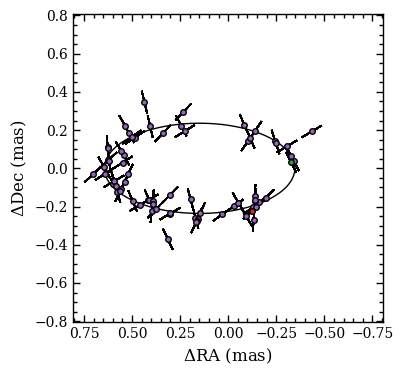

In [23]:
fig = bin_model.plot_orbit(model_param=model_param, plot_file=None)

In [24]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


---------------------
Orbit (12-parameters)
---------------------



  0%|          | 0/125000 [00:00<?, ?it/s]

Best-fit parameters (RUWE = 1.043):
   - RA = 49.924 deg +/- 0.018 mas
   - Dec = 20.011 deg +/- 0.013 mas
   - Parallax = 24.999 +/- 0.015 mas
   - mu in RA = -30.008 +/- 0.010 mas/yr
   - mu in Dec = 30.004 +/- 0.007 mas/yr
   - Thiele-Innes B = -0.496 +/- 0.020
   - Thiele-Innes G = 0.033 +/- 0.022
   - Thiele-Innes A = 0.010 +/- 0.014
   - Thiele-Innes F = 0.271 +/- 0.017
   - Semi-major axis = 2.603 au
   - Eccentricity = 0.380
   - Relative time of periastron = 0.01


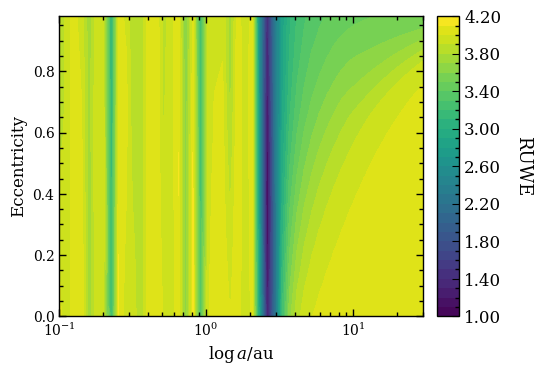

In [25]:
fig = leastsq.orbit_grid(plot_file='ruwe_orbit.png')

In [26]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom)
# sampler = NestedSampler(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 16.147
RUWE = 4.018
Inflation factor = 4.039

Best-fit parameters:
   - RA = 50.245 deg +/- 0.050 mas
   - Dec = 19.981 deg +/- 0.036 mas
   - Parallax = 25.018 +/- 0.056 mas
   - mu in RA = -30.013 +/- 0.034 mas/yr
   - mu in Dec = 29.950 +/- 0.020 mas/yr

--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 16.490
RUWE = 4.061
Inflation factor = 4.082

Best-fit parameters:
   - RA = 50.207 deg +/- 0.073 mas
   - Dec = 19.993 deg +/- 0.059 mas
   - Parallax = 25.017 +/- 0.057 mas
   - mu in RA = -30.020 +/- 0.036 mas/yr
   - mu in Dec = 29.955 +/- 0.021 mas/yr
   - dmu/dt in RA = 0.035 +/- 0.050 mas/yr^2
   - dmu/dt in Dec = -0.008 +/- 0.032 mas/yr^2

--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 16.493
RUWE = 4.061
Inflation factor = 4.083

Best-fit parameters:
   - RA = 50.202 deg +/- 0.074

In [27]:
sampler.run_ptmcmc(
    pickle_file='exogaia.pkl',
    n_temps=10,
    n_walkers=100,
    n_steps=10000,
    n_sweeps=1,
    progress=False,
)

The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [ 962.2619227   975.03910084  984.6872715   838.77537924  822.61867383
  290.86991795 1009.982035    912.01110706  948.0430348   857.15784681
  965.42474609  993.20276548  823.87769655]
The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [ 955.54794732  926.11974231  920.62875407  948.15729641  887.1842507
  733.70239483 1053.30820746  849.54950232 1006.86500071  895.50712414
  939.44763376 1026.13924352  885.34296513]
The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [984.75041622 976.4048528  937.22938547 862.47589069 866.66340431
 746.17382636 904.5718792  884.7032086  889.06096539 907.04613818
 918.

## Plot results from orbit fit

In [28]:
results = FitResults(burnin=5000, pickle_file='exogaia.pkl')


-----------
Fit results
-----------

Number of parameters: 13
Samples shape: (10, 10000, 100, 13)

Burnin: 5000
Samples shape: (10, 5000, 100, 13)

Reshaped samples: (5000000, 13)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1


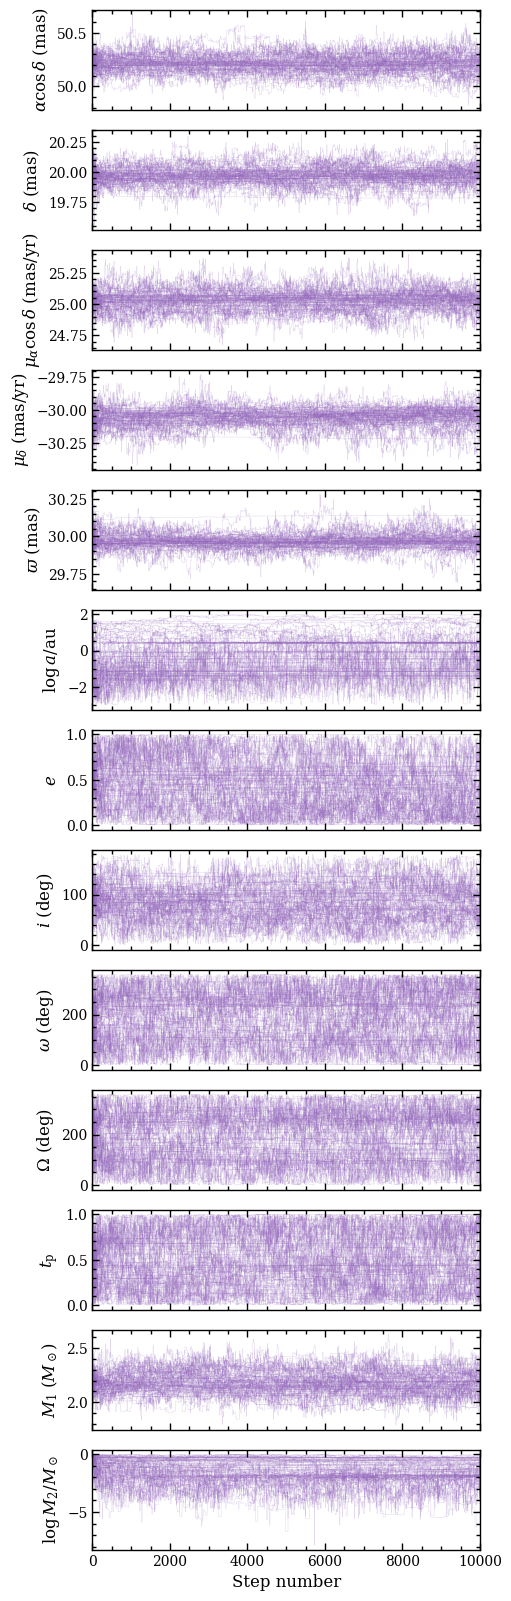

In [29]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file=None)


--------------
Plot posterior
--------------



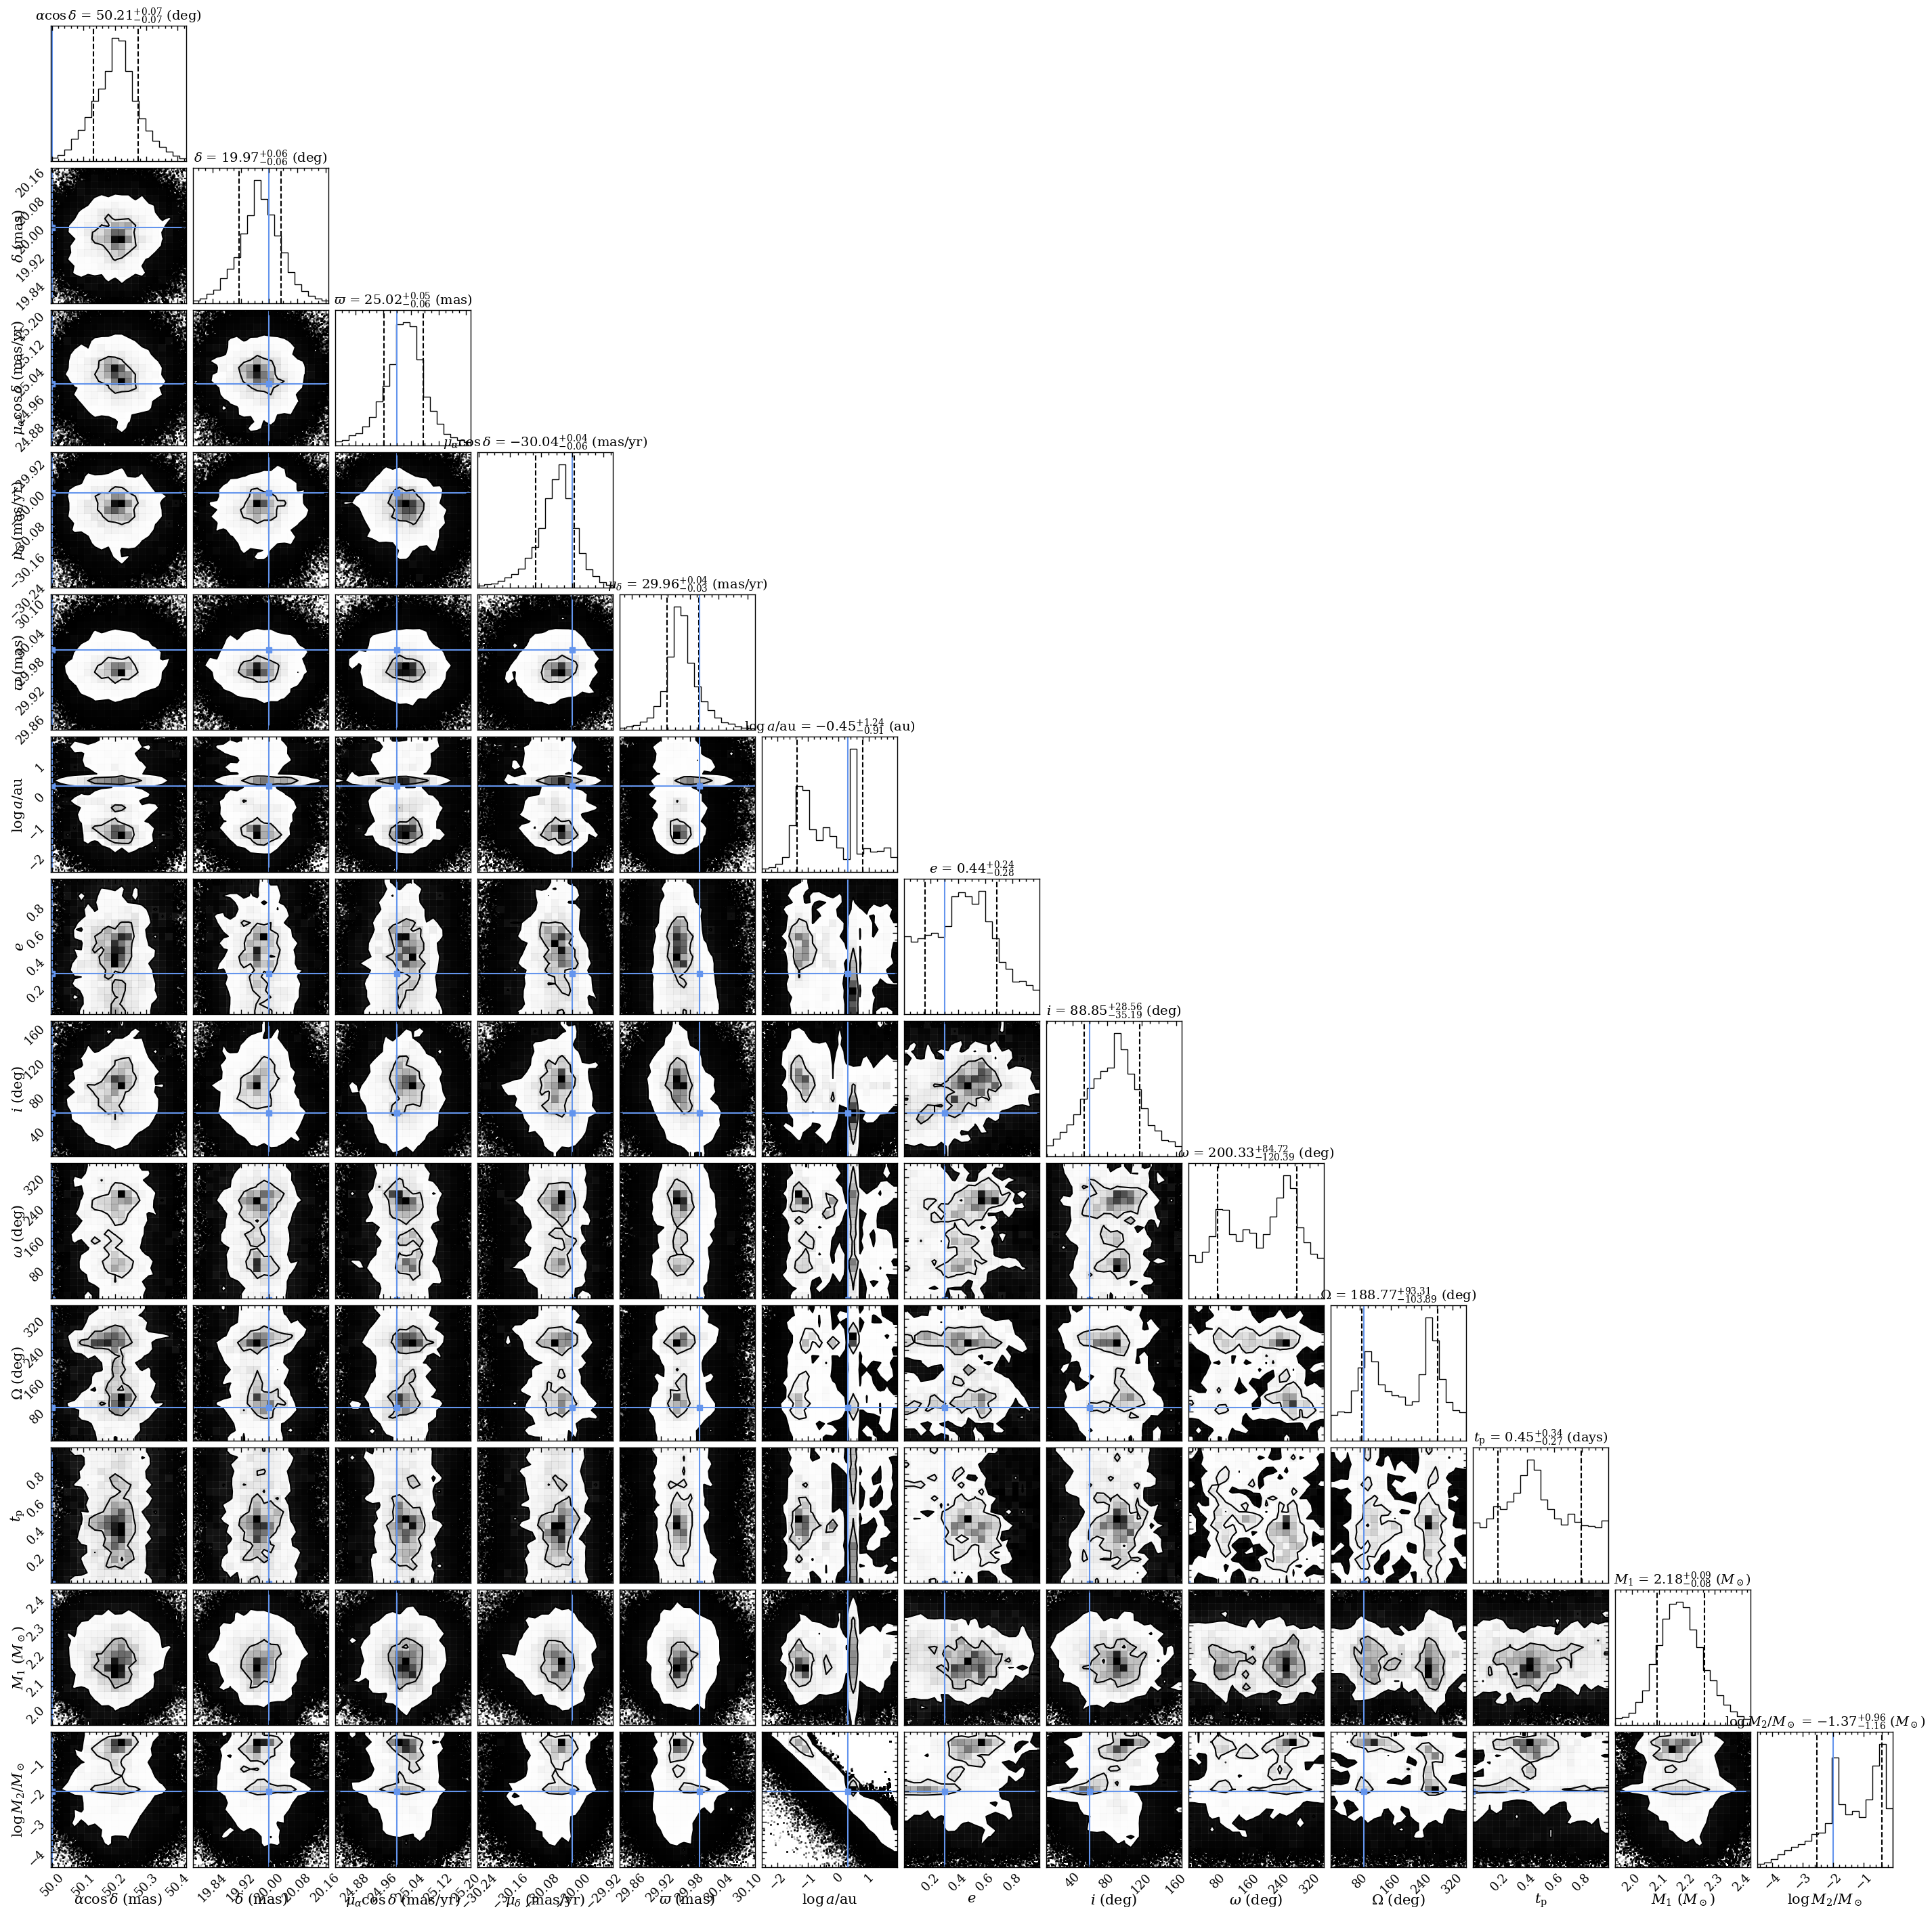

In [30]:
fig = results.plot_posterior(truths=model_param, plot_file=None)


--------------
Plot residuals
--------------


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 50.15
   - Dec (deg) = 20.06
   - Parallax (mas) = 25.01
   - Proper motion in RA (mas/yr) = -29.99
   - Proper motion in Dec (mas/yr) = 30.01

Orbit parameters:
   - Primary mass (Msun) = 1.96
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 2.55
   - Eccentricity = 0.15
   - Inclination (deg) = 54.48
   - Argument of periastron (deg) = 211.00
   - PA of ascending node (deg) = 271.78
   - Relative time of periastron = 0.09


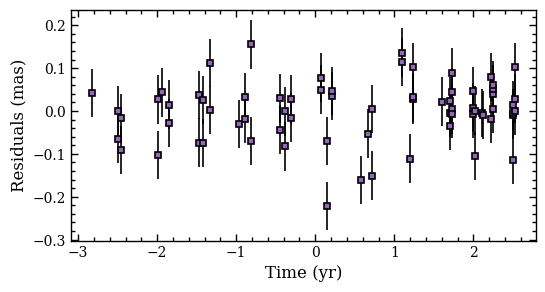

In [31]:
fig = results.plot_residuals(plot_file=None)


----------
Plot orbit
----------



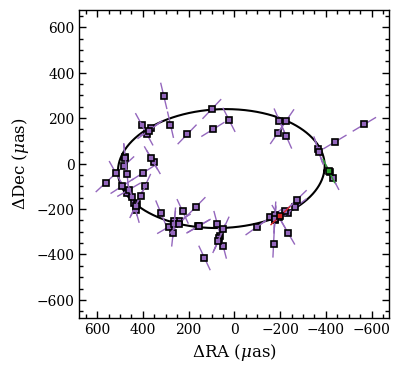

In [32]:
fig = results.plot_orbit(plot_file=None)